# Life Expectancy Prediction using ANN (Regression)

This notebook builds an Artificial Neural Network using **TensorFlow / Keras** to predict the **Life Expectancy (in years)** of a country, given various health, economic, and social indicators.

**Dataset**: WHO Life Expectancy Data (2000-2015) - 2,938 country-year observations across 193 countries.

**Target**:
- `Life expectancy` - Average life expectancy in years

**Feature Groups**:
- Demographic: `Year`, `Status` (Developing / Developed)
- Mortality: `Adult Mortality`, `infant deaths`, `under-five deaths`, `HIV/AIDS`
- Immunization: `Hepatitis B`, `Polio`, `Diphtheria`, `Measles`
- Economic: `GDP`, `percentage expenditure`, `Total expenditure`, `Income composition of resources`
- Social: `Schooling`, `Alcohol`, `Population`, `BMI`, `thinness 1-19 years`, `thinness 5-9 years`

**Pipeline**:
- Clean column names & encode categoricals
- Median imputation grouped by Country
- Drop highly correlated features
- `Dense` + `BatchNormalization` + `Dropout` layers
- `EarlyStopping` callback

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')

I0000 00:00:1787236894.089396    9334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787236894.090112    9334 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787236894.507056    9334 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787236896.617446    9334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Life Expectancy Data.csv")
pd.set_option('display.max_columns', None)
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.shape

(2938, 22)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [5]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


## 3. Data Cleaning

Several issues need fixing before modeling:
1. Column names contain leading / trailing whitespace.
2. The target (`Life expectancy`) has 10 missing values - drop those rows.
3. Many numeric columns have missing values - impute with **country-level median**, then global median for any leftovers.
4. `Status` is binary categorical (Developing / Developed) - encode it.
5. `Country` has 193 unique values (high cardinality) - we keep it for EDA & imputation, then drop before modeling.

### 3.1 Clean Column Names

In [6]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


### 3.2 Drop Rows with Missing Target

In [7]:
target = "Life expectancy"
print("Missing target rows:", df[target].isnull().sum())

df = df.dropna(subset=[target]).reset_index(drop=True)
print("Shape after dropping:", df.shape)

Missing target rows: 10
Shape after dropping: (2928, 22)


### 3.3 Check Duplicates

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 3.4 Encode `Status` (Developing=0, Developed=1)

In [9]:
print("Status values:", df['Status'].unique())
df['Status'] = df['Status'].map({'Developing': 0, 'Developed': 1})
df['Status'].value_counts()

Status values: <ArrowStringArray>
['Developing', 'Developed']
Length: 2, dtype: str


Status
0    2416
1     512
Name: count, dtype: int64

### 3.5 Visualize Missing Values (Before Imputation)

In [10]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
print("Columns with missing values (%):")
print(miss_pct.round(2))

Columns with missing values (%):
Population                         21.99
Hepatitis B                        18.89
GDP                                15.13
Total expenditure                   7.72
Alcohol                             6.59
Income composition of resources     5.46
Schooling                           5.46
thinness  1-19 years                1.09
thinness 5-9 years                  1.09
BMI                                 1.09
Diphtheria                          0.65
Polio                               0.65
dtype: float64


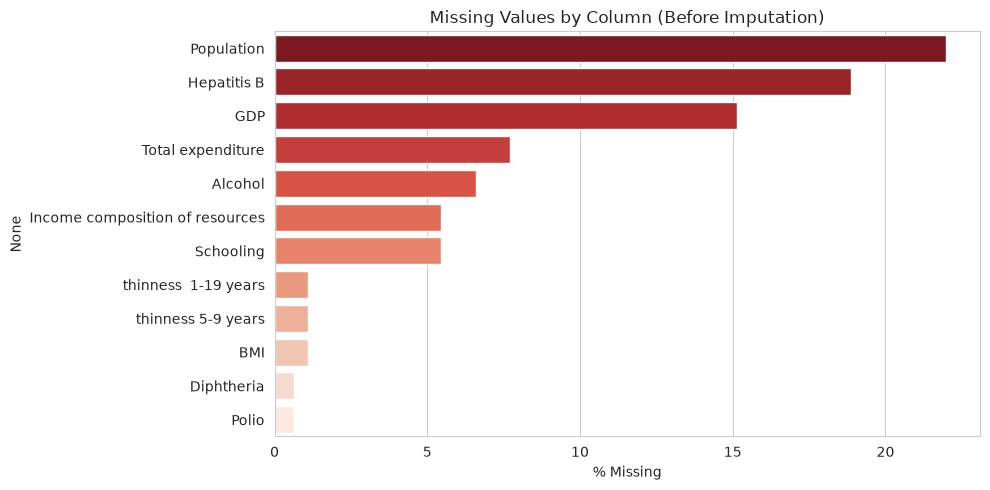

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=miss_pct.values,
    y=miss_pct.index,
    hue=miss_pct.index,
    palette="Reds_r",
    legend=False
)

plt.xlabel("% Missing")
plt.title("Missing Values by Column (Before Imputation)")
plt.tight_layout()
plt.show()

### 3.6 Impute Missing Values

Strategy: first fill each numeric column with the **median of its country** (since values like GDP, Population, BMI are country-specific). For any country that has *no* observation at all for a column, fall back to the **global median**.

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Step 1: Fill with country median
for col in numeric_cols:
    country_median = df.groupby("Country")[col].transform("median")
    df[col] = df[col].fillna(country_median)

# Step 2: Fill any remaining missing values with overall median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values AFTER imputation:")
print(df.isnull().sum().sum())

Missing values AFTER imputation:
0


## 4. Exploratory Data Analysis

### 4.1 Status Distribution (Developed vs Developing)

How imbalanced is our `Status` label?

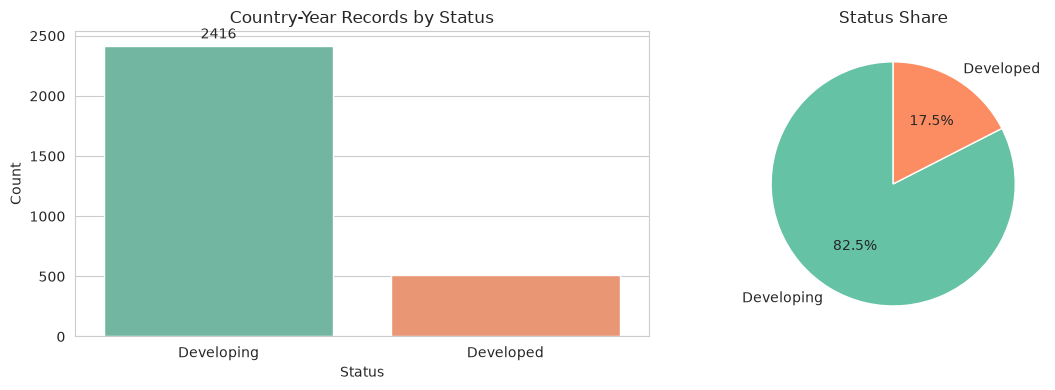

In [13]:
status_counts = df["Status"].value_counts().rename({0: "Developing", 1: "Developed"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

# Bar
sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,
    palette="Set2",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Country-Year Records by Status")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0], padding=3)

# Pie
axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2"),
    startangle=90
)
axes[1].set_title("Status Share")

plt.tight_layout()
plt.show()

`Most of the records are from developing countries (82.5%), while only 17.5% are from developed countries. This means the dataset mainly contains data from developing countries.`

### 4.2 Life Expectancy by Status

Boxplot - do Developed countries have noticeably higher life expectancy?

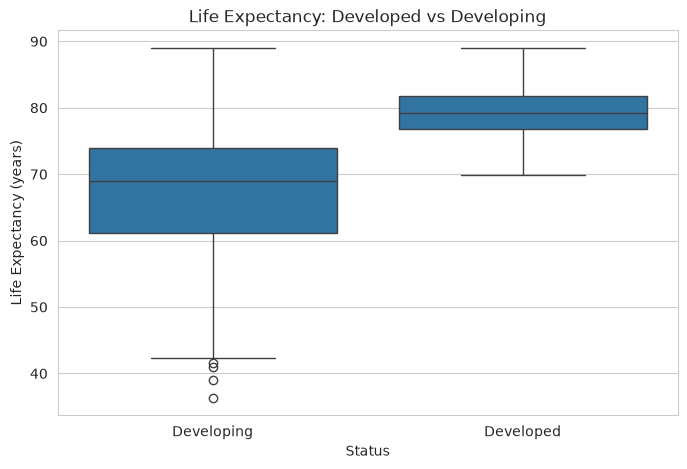

,Life expectancy
Status,
Developing,69.00
Developed,79.25


In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df['Status'].map({0: 'Developing', 1: 'Developed'}),
    y=df[target]
)
plt.title('Life Expectancy: Developed vs Developing')
plt.xlabel('Status')
plt.ylabel('Life Expectancy (years)')
plt.show()

pd.DataFrame(df.groupby("Status")[target].median().round(2)).rename(
    index={0: "Developing", 1: "Developed"}
) 

### 4.3 Life Expectancy Trend Over Years

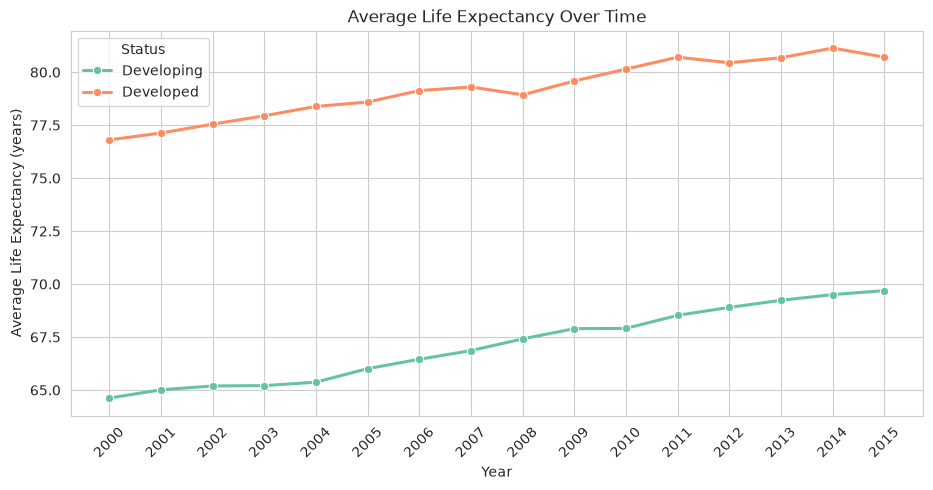

In [15]:
yearly = df.groupby(['Year', 'Status'])[target].mean().reset_index()
yearly['Status'] = yearly['Status'].map({0: 'Developing', 1: 'Developed'})

plt.figure(figsize=(11, 5))
sns.lineplot(data=yearly, x='Year', y=target, hue='Status',
             marker='o', palette='Set2', linewidth=2.2)
plt.title('Average Life Expectancy Over Time')
plt.ylabel('Average Life Expectancy (years)')
plt.xticks(yearly['Year'].unique(), rotation=45)
plt.show()

### 4.4 Top 10 & Bottom 10 Countries by Average Life Expectancy

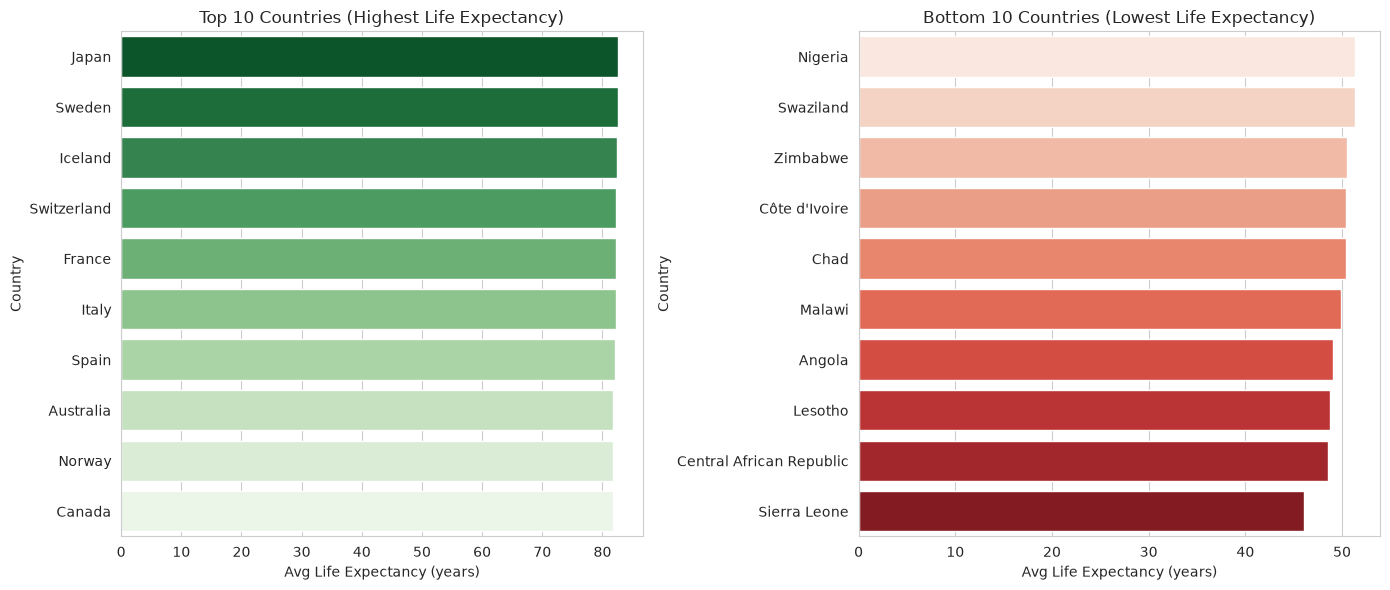

In [16]:
country_avg = df.groupby("Country")[target].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

# Top 10
top10 = country_avg.tail(10)
top10 = top10.sort_values(ascending=False)
sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette="Greens_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Top 10 Countries (Highest Life Expectancy)")
axes[0].set_xlabel("Avg Life Expectancy (years)")


# Bottom 10
bot10 = country_avg.head(10)
bot10 = bot10.sort_values(ascending=False)
sns.barplot(
    x=bot10.values,
    y=bot10.index,
    hue=bot10.index,
    palette="Reds",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Bottom 10 Countries (Lowest Life Expectancy)")
axes[1].set_xlabel("Avg Life Expectancy (years)")

plt.tight_layout()
plt.show()

### 4.5 Drop `Country` Column

We've used it for grouped imputation and EDA. With 193 unique values, one-hot encoding would create 193 sparse columns - drop it before further modeling steps.

In [17]:
df = df.drop(columns=['Country'])
print("Shape after dropping Country:", df.shape)

Shape after dropping Country: (2928, 21)


### 4.6 Correlation Heatmap

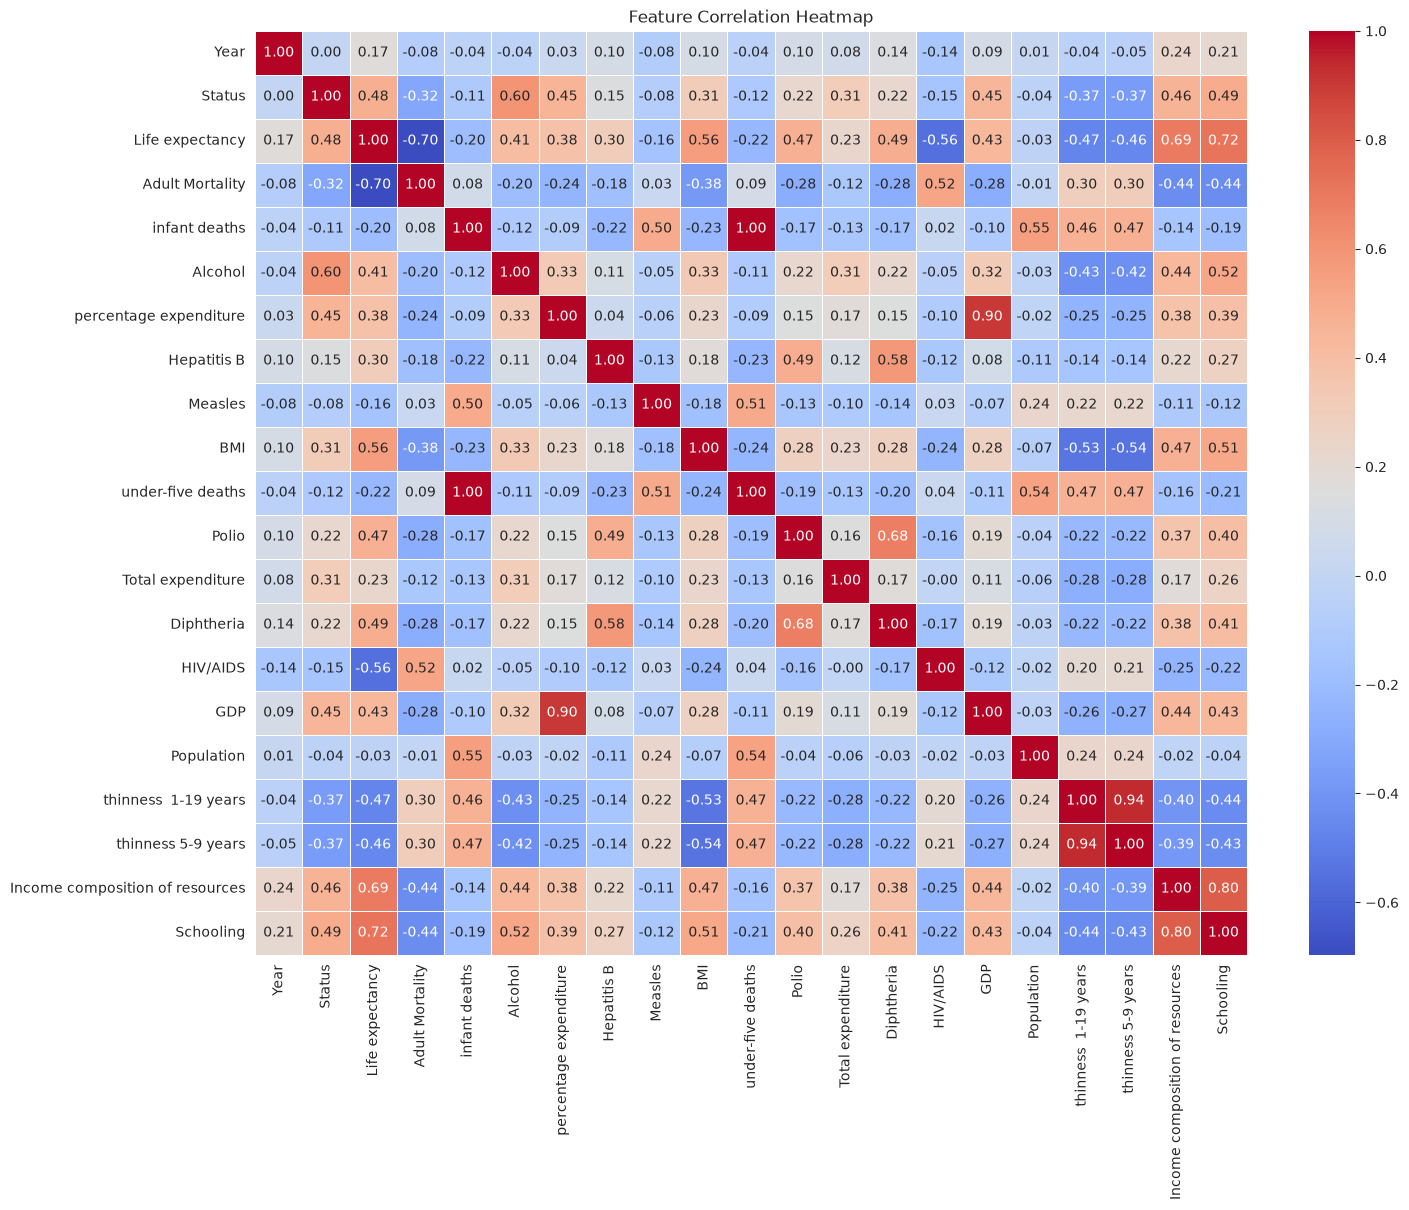

In [18]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### 4.7 Feature Correlation with Target

Which features push life expectancy up vs down?

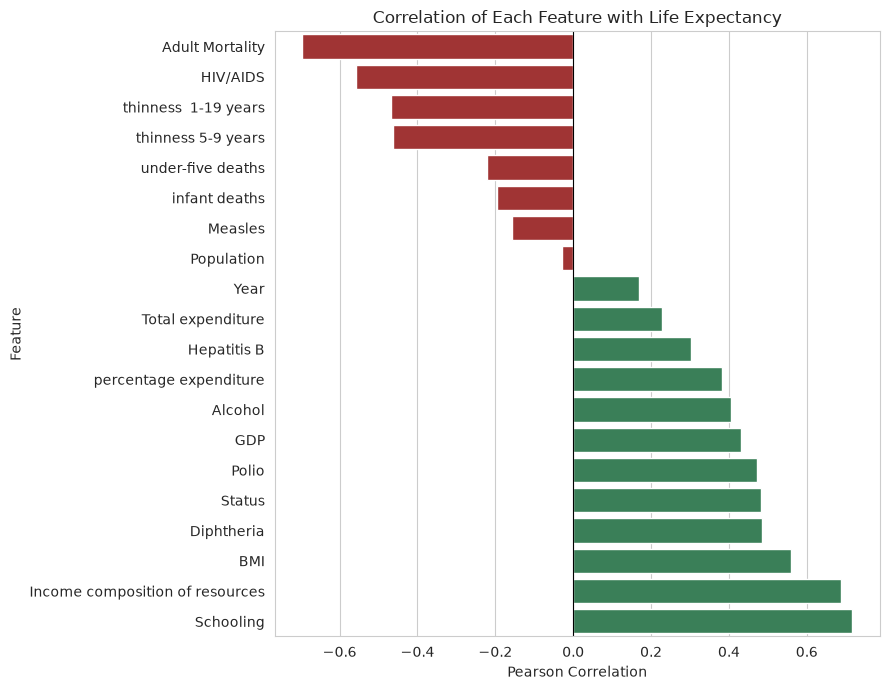

In [19]:
target_corr = (
    df.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values()
    .reset_index()
)

target_corr.columns = ["Feature", "Correlation"]

colors = [
    "firebrick" if c < 0 else "seagreen"
    for c in target_corr["Correlation"]
]

plt.figure(figsize=(9, 7))

sns.barplot(
    data=target_corr,
    x="Correlation",
    y="Feature",
    hue="Feature",
    palette=colors,
    legend=False
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Each Feature with Life Expectancy")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

### 4.9 Droping Less Importance Feature

`Population and Year correlations are very close to 0 so dropping them `

In [20]:
df = df.drop(columns=["Year", "Population"])

### 4.10 Drop Highly Correlated Features (|corr| > 0.8)

Pairs like `infant deaths` & `under-five deaths`, or `thinness 1-19` & `thinness 5-9` carry duplicate information.

In [21]:
X_tmp = df.drop(columns=[target])
corr_matrix = X_tmp.corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8:
            col1 = corr_matrix.columns[j]
            col2 = corr_matrix.columns[i]
            corr = corr_matrix.iloc[i, j]
            print(f"{col1} <-> {col2} = {corr:.3f}")
            columns_to_drop.append(col2)

columns_to_drop = list(set(columns_to_drop))
print("\nColumns to drop:", columns_to_drop)

infant deaths <-> under-five deaths = 0.997
percentage expenditure <-> GDP = 0.902
thinness  1-19 years <-> thinness 5-9 years = 0.939

Columns to drop: ['under-five deaths', 'thinness 5-9 years', 'GDP']


In [22]:
df = df.drop(columns=columns_to_drop)
print("Shape after dropping correlated features:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping correlated features: (2928, 16)
Remaining columns: ['Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'Income composition of resources', 'Schooling']


### 4.11 Target Distribution

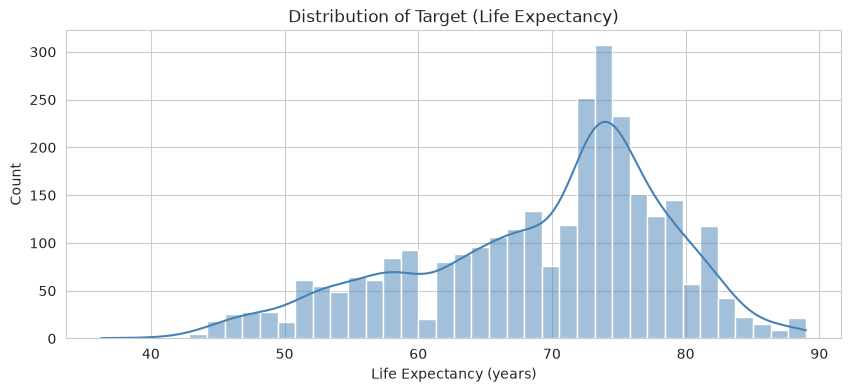

In [23]:
plt.figure(figsize=(10, 4))
sns.histplot(df[target], kde=True, bins=40, color='steelblue')
plt.title('Distribution of Target (Life Expectancy)')
plt.xlabel('Life Expectancy (years)')
plt.show()

### 4.12 Top Features vs Target (Scatter)

In [24]:
target_corr_abs = df.corr()[target].drop(target).abs().sort_values(ascending=False)
top_features = target_corr_abs.head(6).index.tolist()
print("Top 6 features by |corr| with target:")
print(target_corr_abs.head(6))

Top 6 features by |corr| with target:
Schooling                          0.717314
Adult Mortality                    0.696359
Income composition of resources    0.688591
BMI                                0.558888
HIV/AIDS                           0.556556
Diphtheria                         0.485097
Name: Life expectancy, dtype: float64


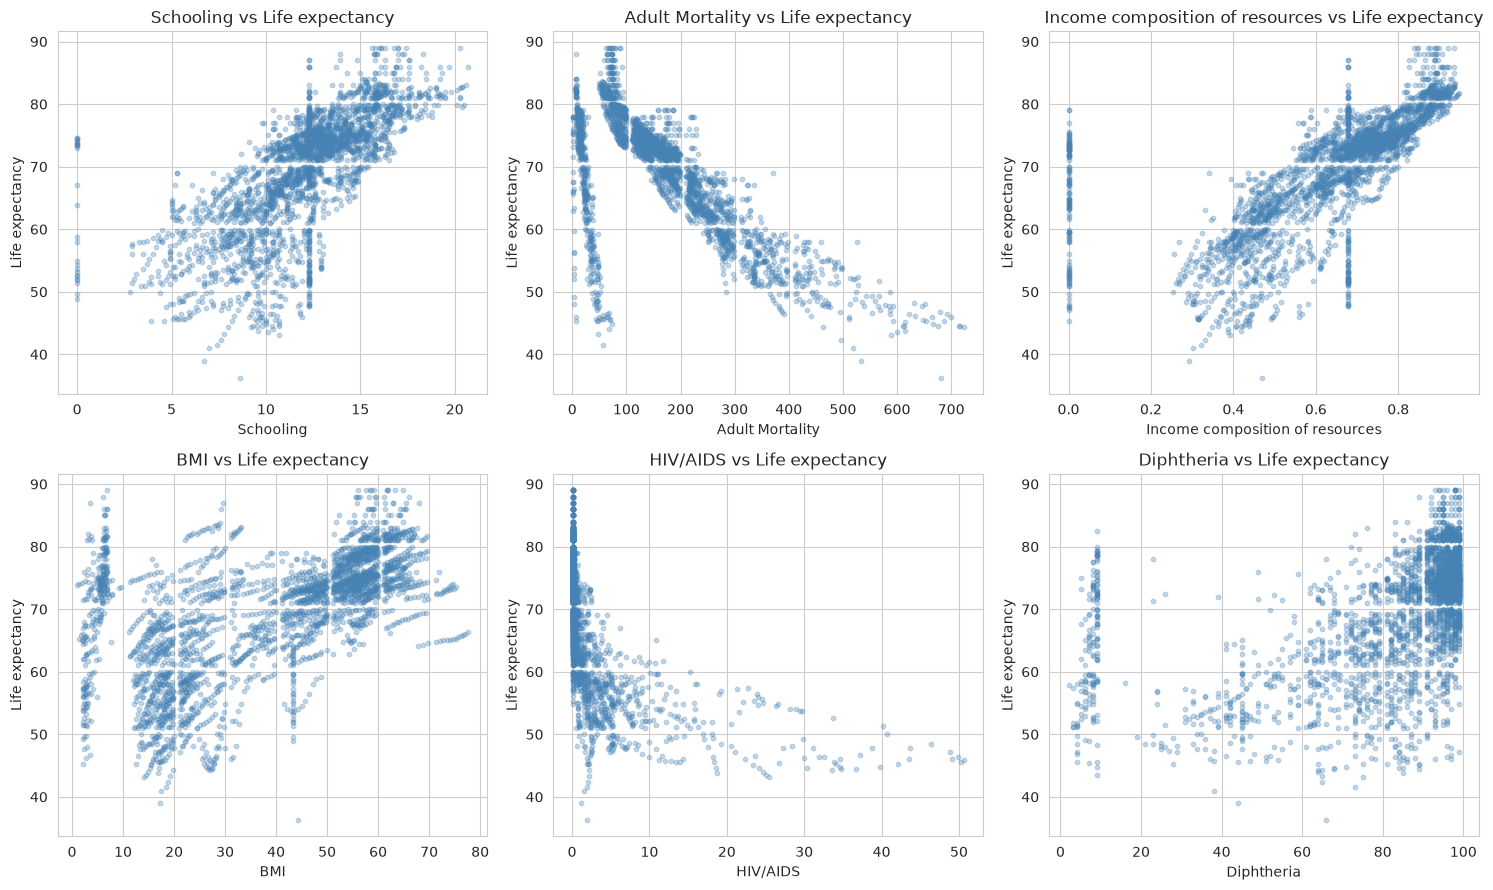

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    ax.scatter(df[col], df[target], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'{col} vs {target}')

plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [26]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (2342, 15)  X_test: (586, 15)
y_train: (2342,)  y_test: (586,)


## 6. Feature Scaling

Only the **features (X)** are scaled with `MinMaxScaler`. The target `Life expectancy` is kept in its original scale (years) so all metrics are directly interpretable.

In [27]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print("n_features:", n_features)

n_features: 15


## 7. Build the ANN

A 3-hidden-layer network (128 -> 64 -> 32) with BatchNormalization and Dropout for regularization.

In [28]:
model = Sequential()

# Input layer
model.add(Input(shape=(n_features,)))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

# Output layer
model.add(Dense(1, activation='linear'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

E0000 00:00:1787237517.238739    9334 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

## 8. Train the Model

`EarlyStopping` halts training once the validation loss stops improving and restores the best weights.

In [29]:
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.01,
    patience=25,
    verbose=1,
    mode="min",
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4829.2661 - mae: 69.0824 - val_loss: 4692.2310 - val_mae: 67.8621
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4718.0132 - mae: 68.4502 - val_loss: 4556.7617 - val_mae: 66.9581
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4568.8823 - mae: 67.4165 - val_loss: 4452.2173 - val_mae: 66.2743
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4375.9414 - mae: 65.9841 - val_loss: 4428.2046 - val_mae: 66.1483
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4116.5381 - mae: 63.9792 - val_loss: 4079.8582 - val_mae: 63.5509
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3802.3105 - mae: 61.4677 - val_loss: 3745.8291 - val_mae: 60.9537
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3444.6763 - mae: 58.4827 - val_loss: 3376.3274 - val_mae: 57.8850
Epoch 8/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3056.7698 - mae: 55.0410 - val_loss: 2903.7043 - val_mae: 53.7048


## 9. Training History

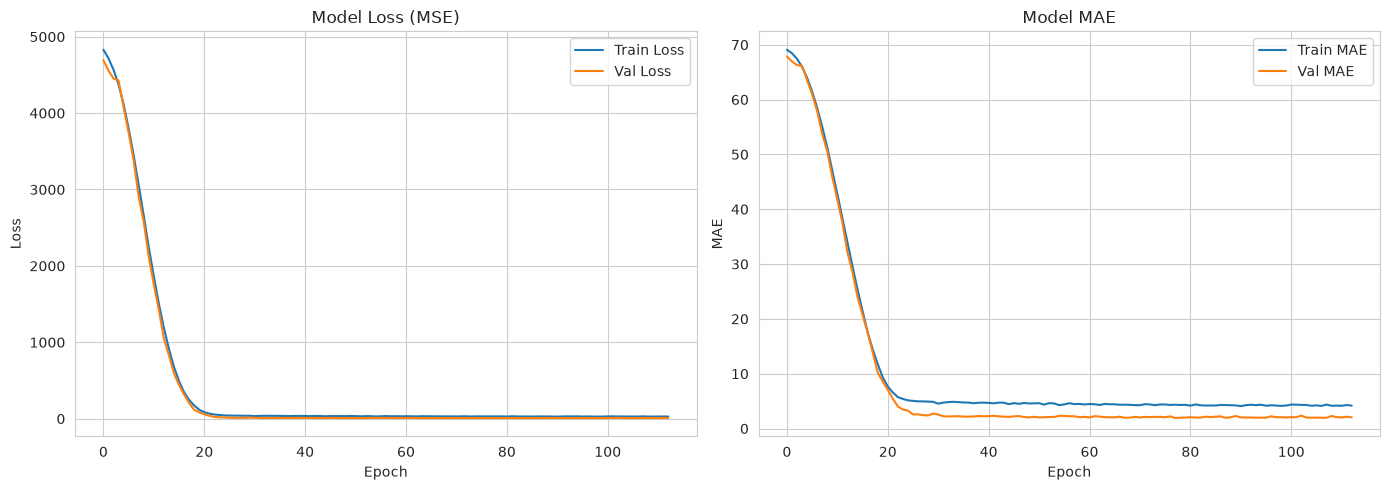

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

In [31]:
y_pred = model.predict(X_test_scaled).flatten()

y_test_arr = y_test.values
for actual, pred in zip(y_test_arr[10:20], y_pred[10:20]):
    print(f"Actual: {actual:>6.2f}   Predicted: {pred:>6.2f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Actual:  78.50   Predicted:  80.39
Actual:  75.30   Predicted:  74.87
Actual:  74.90   Predicted:  74.44
Actual:  79.30   Predicted:  80.61
Actual:  68.30   Predicted:  69.44
Actual:  75.00   Predicted:  70.73
Actual:  77.00   Predicted:  71.12
Actual:  53.40   Predicted:  54.27
Actual:  67.00   Predicted:  57.84
Actual:  52.50   Predicted:  54.69


In [32]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R\u00b2 Score : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

R² Score : 0.9318
MAE       : 1.7148
RMSE      : 2.4580


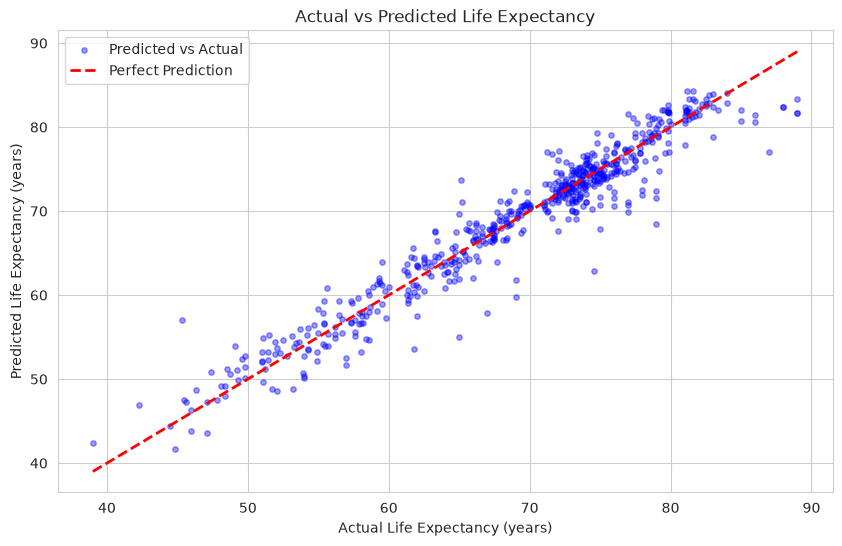

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.4, s=15, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Life Expectancy (years)')
plt.ylabel('Predicted Life Expectancy (years)')
plt.title('Actual vs Predicted Life Expectancy')
plt.legend()
plt.show()

## 11. Inference on New Data

Helper that takes a raw record (matching the **final feature set** after correlation pruning), applies the same scaling pipeline, then predicts using the trained ANN.

In [34]:
df.head()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,Income composition of resources,Schooling
0,0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,6.0,8.16,65.0,0.1,17.2,0.479,10.1
1,0,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,58.0,8.18,62.0,0.1,17.5,0.476,10.0
2,0,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,62.0,8.13,64.0,0.1,17.7,0.470,9.9
3,0,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,67.0,8.52,67.0,0.1,17.9,0.463,9.8
4,0,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,68.0,7.87,68.0,0.1,18.2,0.454,9.5


In [35]:
import pandas as pd

# Feature columns used during training
feature_cols = X.columns.tolist()

# Take the second sample from the test set
sample = X_test.iloc[1]

# Prepare input
input_df = pd.DataFrame([sample])[feature_cols]
input_scaled = scaler.transform(input_df)

# Predict
prediction = model.predict(input_scaled, verbose=0)
final_prediction = prediction.flatten()[0]

# Display results
print(f"Predicted Life Expectancy: {final_prediction:.2f} years")
print(f"Actual Life Expectancy: {y_test.iloc[1]:.2f} years")

Predicted Life Expectancy: 71.41 years
Actual Life Expectancy: 71.80 years


### Save the model and scaler

In [36]:
import joblib

# Save the model
model.save("life_expectancy_model.keras")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature order
joblib.dump(X.columns.tolist(), "feature_cols.pkl")

['feature_cols.pkl']

### Load and predict

In [37]:
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# Load model, scaler, and feature order
model = load_model("life_expectancy_model.keras")
scaler = joblib.load("scaler.pkl")
feature_cols = joblib.load("feature_cols.pkl")

# Your input values
sample = {
    "Status": 0.000,
    "Adult Mortality": 129.000,
    "infant deaths": 92.000,
    "Alcohol": 0.010,
    "percentage expenditure": 0.000,
    "Hepatitis B": 97.000,
    "Measles": 240.000,
    "BMI": 18.300,
    "Polio": 97.000,
    "Total expenditure": 2.800,
    "Diphtheria": 97.000,
    "HIV/AIDS": 0.100,
    "thinness  1-19 years": 17.900,
    "Income composition of resources": 0.575,
    "Schooling": 10.200
}

# Convert to DataFrame in correct feature order
input_df = pd.DataFrame([sample])[feature_cols]

# Scale
input_scaled = scaler.transform(input_df)

# Predict
prediction = model.predict(input_scaled, verbose=0).flatten()[0]

actual = 71.80  
print(f"Predicted Life Expectancy: {prediction:.2f} years")
print(f"Actual Life Expectancy: {actual:.2f} years")

Predicted Life Expectancy: 71.41 years
Actual Life Expectancy: 71.80 years
